In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

In [35]:
DATA_FOLDER = '../data/raw/'        # Folder containing UNSW-NB15_*.csv files
OUTPUT_FILE = '../data/processed/cleaned_data.csv'

# UNSW-NB15 official 49 feature names (from NUSW-NB15_features.csv)
UNSW_COLUMNS = [
    'srcip', 'sport', 'dstip', 'dsport', 'proto',
    'state', 'dur', 'sbytes', 'dbytes', 'sttl',
    'dttl', 'sloss', 'dloss', 'service', 'sload',
    'dload', 'spkts', 'dpkts', 'swin', 'dwin',
    'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth',
    'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime',
    'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat',
    'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd',
    'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label'
]

all_files = sorted(glob.glob(os.path.join(DATA_FOLDER, 'UNSW-NB15_*.csv')))
print(f'Found {len(all_files)} UNSW-NB15 files:')
for f in all_files:
    print(f'  → {os.path.basename(f)}')

Found 5 UNSW-NB15 files:
  → UNSW-NB15_1.csv
  → UNSW-NB15_2.csv
  → UNSW-NB15_3.csv
  → UNSW-NB15_4.csv
  → UNSW-NB15_LIST_EVENTS.csv


In [36]:
dfs = []

for file in all_files:
    print(f'Loading: {os.path.basename(file)} ...', end=' ')
    try:
        tmp = pd.read_csv(file, header=None, names=UNSW_COLUMNS,
                          encoding='utf-8', low_memory=False)
    except UnicodeDecodeError:
        tmp = pd.read_csv(file, header=None, names=UNSW_COLUMNS,
                          encoding='latin-1', low_memory=False)

    # Normalize attack_cat
    tmp['attack_cat'] = tmp['attack_cat'].astype(str).str.strip()
    tmp['attack_cat'] = tmp['attack_cat'].replace({'nan': 'Normal', '': 'Normal'})

    # Ensure binary label is integer
    tmp['label'] = pd.to_numeric(tmp['label'], errors='coerce').fillna(0).astype(int)

    dfs.append(tmp)
    print(f'{len(tmp):,} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\n Full dataset loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loading: UNSW-NB15_1.csv ... 700,001 rows
Loading: UNSW-NB15_2.csv ... 700,001 rows
Loading: UNSW-NB15_3.csv ... 700,001 rows
Loading: UNSW-NB15_4.csv ... 440,044 rows
Loading: UNSW-NB15_LIST_EVENTS.csv ... 209 rows

 Full dataset loaded: 2,540,256 rows, 49 columns


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132.0,164.0,31.0,...,0,3.0,7.0,1.0,3.0,1.0,1.0,1.0,Normal,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528.0,304.0,31.0,...,0,2.0,4.0,2.0,3.0,1.0,1.0,2.0,Normal,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146.0,178.0,31.0,...,0,12.0,8.0,1.0,2.0,2.0,1.0,1.0,Normal,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132.0,164.0,31.0,...,0,6.0,9.0,1.0,1.0,1.0,1.0,1.0,Normal,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146.0,178.0,31.0,...,0,7.0,9.0,1.0,1.0,1.0,1.0,1.0,Normal,0


In [37]:
print('All UNSW-NB15 column names:')
for col in df.columns.tolist():
    print(f'  {col}')

All UNSW-NB15 column names:
  srcip
  sport
  dstip
  dsport
  proto
  state
  dur
  sbytes
  dbytes
  sttl
  dttl
  sloss
  dloss
  service
  sload
  dload
  spkts
  dpkts
  swin
  dwin
  stcpb
  dtcpb
  smeansz
  dmeansz
  trans_depth
  res_bdy_len
  sjit
  djit
  stime
  ltime
  sintpkt
  dintpkt
  tcprtt
  synack
  ackdat
  is_sm_ips_ports
  ct_state_ttl
  ct_flw_http_mthd
  is_ftp_login
  ct_ftp_cmd
  ct_srv_src
  ct_srv_dst
  ct_dst_ltm
  ct_src_ltm
  ct_src_dport_ltm
  ct_dst_sport_ltm
  ct_dst_src_ltm
  attack_cat
  label


In [21]:
df = pd.read_csv(
    OUTPUT_FILE,
    encoding='latin-1',
    low_memory=False,
    on_bad_lines='skip'
)

print(f'Loaded sampled data')
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
df.head()

Loaded sampled data
Rows    : 1,656,851
Columns : 81


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,21,6,14/02/2018 10:43:25,1,1,1,0,0,0,0,...,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce,02-14-2018.csv
1,21,6,14/02/2018 10:53:58,1,1,1,0,0,0,0,...,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce,02-14-2018.csv
2,21,6,14/02/2018 10:50:25,1,1,1,0,0,0,0,...,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce,02-14-2018.csv
3,21,6,14/02/2018 10:48:10,2,1,1,0,0,0,0,...,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce,02-14-2018.csv
4,21,6,14/02/2018 10:50:31,18,1,1,0,0,0,0,...,0,0,0,0,0.0,0.0,0,0,FTP-BruteForce,02-14-2018.csv


In [22]:
print('All column names:')
for col in df.columns.tolist():
    print(f'  {col}')

All column names:
  Dst Port
  Protocol
  Timestamp
  Flow Duration
  Tot Fwd Pkts
  Tot Bwd Pkts
  TotLen Fwd Pkts
  TotLen Bwd Pkts
  Fwd Pkt Len Max
  Fwd Pkt Len Min
  Fwd Pkt Len Mean
  Fwd Pkt Len Std
  Bwd Pkt Len Max
  Bwd Pkt Len Min
  Bwd Pkt Len Mean
  Bwd Pkt Len Std
  Flow Byts/s
  Flow Pkts/s
  Flow IAT Mean
  Flow IAT Std
  Flow IAT Max
  Flow IAT Min
  Fwd IAT Tot
  Fwd IAT Mean
  Fwd IAT Std
  Fwd IAT Max
  Fwd IAT Min
  Bwd IAT Tot
  Bwd IAT Mean
  Bwd IAT Std
  Bwd IAT Max
  Bwd IAT Min
  Fwd PSH Flags
  Bwd PSH Flags
  Fwd URG Flags
  Bwd URG Flags
  Fwd Header Len
  Bwd Header Len
  Fwd Pkts/s
  Bwd Pkts/s
  Pkt Len Min
  Pkt Len Max
  Pkt Len Mean
  Pkt Len Std
  Pkt Len Var
  FIN Flag Cnt
  SYN Flag Cnt
  RST Flag Cnt
  PSH Flag Cnt
  ACK Flag Cnt
  URG Flag Cnt
  CWE Flag Count
  ECE Flag Cnt
  Down/Up Ratio
  Pkt Size Avg
  Fwd Seg Size Avg
  Bwd Seg Size Avg
  Fwd Byts/b Avg
  Fwd Pkts/b Avg
  Fwd Blk Rate Avg
  Bwd Byts/b Avg
  Bwd Pkts/b Avg
  Bwd Blk Rate A

In [38]:
print('Data types:')
print(df.dtypes)
print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None ')

Data types:
srcip                object
sport                object
dstip                object
dsport               object
proto                object
state                object
dur                 float64
sbytes              float64
dbytes              float64
sttl                float64
dttl                float64
sloss               float64
dloss               float64
service              object
sload               float64
dload               float64
spkts               float64
dpkts               float64
swin                float64
dwin                float64
stcpb               float64
dtcpb               float64
smeansz             float64
dmeansz             float64
trans_depth         float64
res_bdy_len         float64
sjit                float64
djit                float64
stime               float64
ltime               float64
sintpkt             float64
dintpkt             float64
tcprtt              float64
synack              float64
ackdat              float64
is_sm_ip

Attack category counts:
attack_cat
Normal            2218973
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64


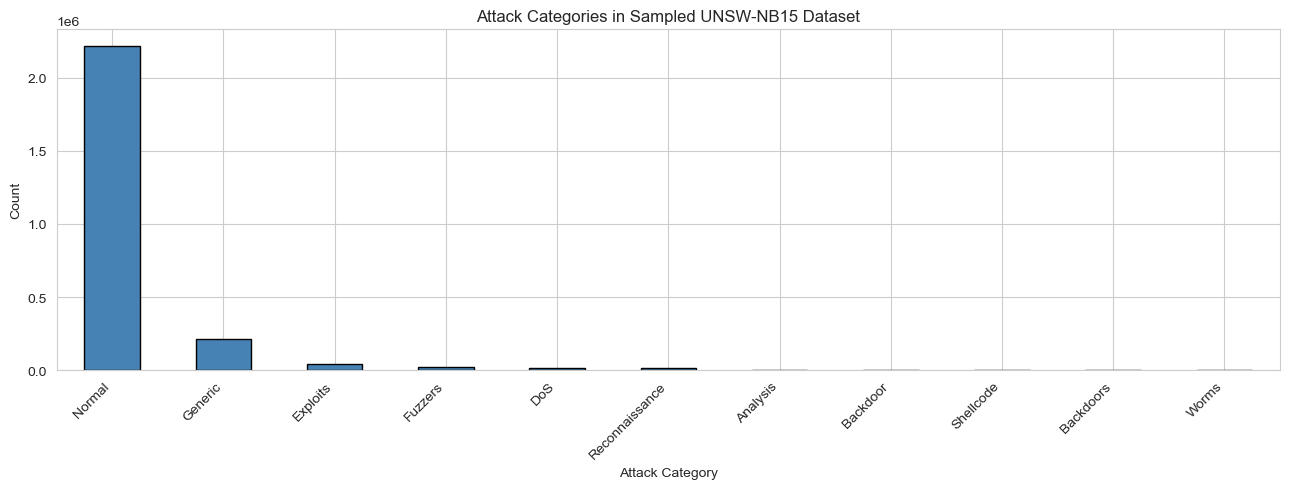

In [39]:
attack_counts = df['attack_cat'].value_counts()
print('Attack category counts:')
print(attack_counts)

plt.figure(figsize=(13, 5))
attack_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attack Categories in Sampled UNSW-NB15 Dataset')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Binary label counts:
binary_label
0    2218973
1     321283
Name: count, dtype: int64

Attack rate: 12.65%


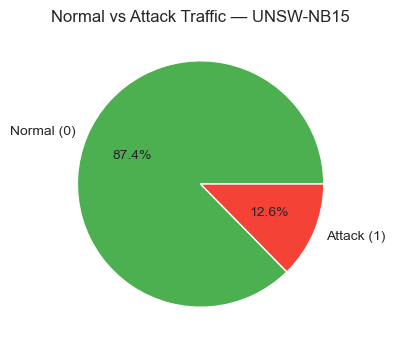

In [40]:
# UNSW-NB15: label is already binary (0 = Normal, 1 = Attack)
df['binary_label'] = df['label'].astype(int)

print('Binary label counts:')
print(df['binary_label'].value_counts())
print(f'\nAttack rate: {df["binary_label"].mean():.2%}')

plt.figure(figsize=(6, 4))
df['binary_label'].value_counts().plot(
    kind='pie',
    labels=['Normal (0)', 'Attack (1)'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336']
)
plt.title('Normal vs Attack Traffic — UNSW-NB15')
plt.ylabel('')
plt.show()

In [ ]:
df.describe().T

In [44]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

inf_count = np.isinf(df[numeric_cols]).sum()
print('Infinite values found:')
print(inf_count[inf_count > 0] if inf_count.sum() > 0 else 'None ✅')

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f'\n After cleaning — rows: {len(df):,}')

Infinite values found:
None ✅

 After cleaning — rows: 1,087,203


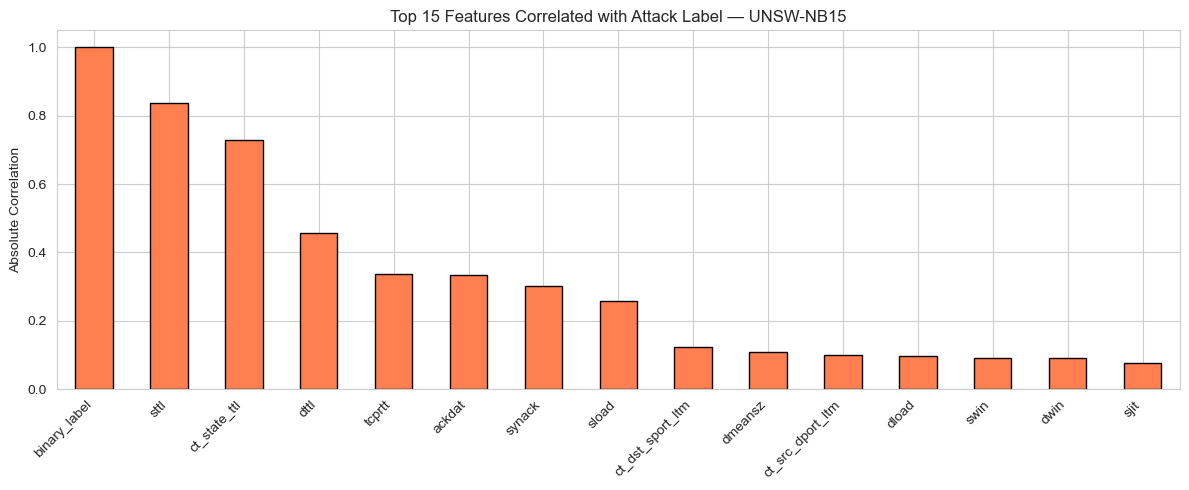

Top 15 features:
binary_label        1.000000
sttl                0.837304
ct_state_ttl        0.730084
dttl                0.456176
tcprtt              0.335536
ackdat              0.332897
synack              0.300338
sload               0.256520
ct_dst_sport_ltm    0.123664
dmeansz             0.109454
ct_src_dport_ltm    0.100853
dload               0.096678
swin                0.089950
dwin                0.089656
sjit                0.075681
dtype: float64


In [45]:
# Drop non-numeric / identifier columns before correlation
drop_cols = ['srcip', 'dstip', 'sport', 'dsport', 'proto',
             'state', 'service', 'attack_cat', 'source_file',
             'label', 'stime', 'ltime']
numeric_cols = df.drop(columns=[c for c in drop_cols if c in df.columns]) \
                 .select_dtypes(include=[np.number]).columns

correlations = df[numeric_cols].corrwith(df['binary_label']).abs().sort_values(ascending=False)
top_corr = correlations.head(15)

plt.figure(figsize=(12, 5))
top_corr.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 15 Features Correlated with Attack Label — UNSW-NB15')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(top_corr)

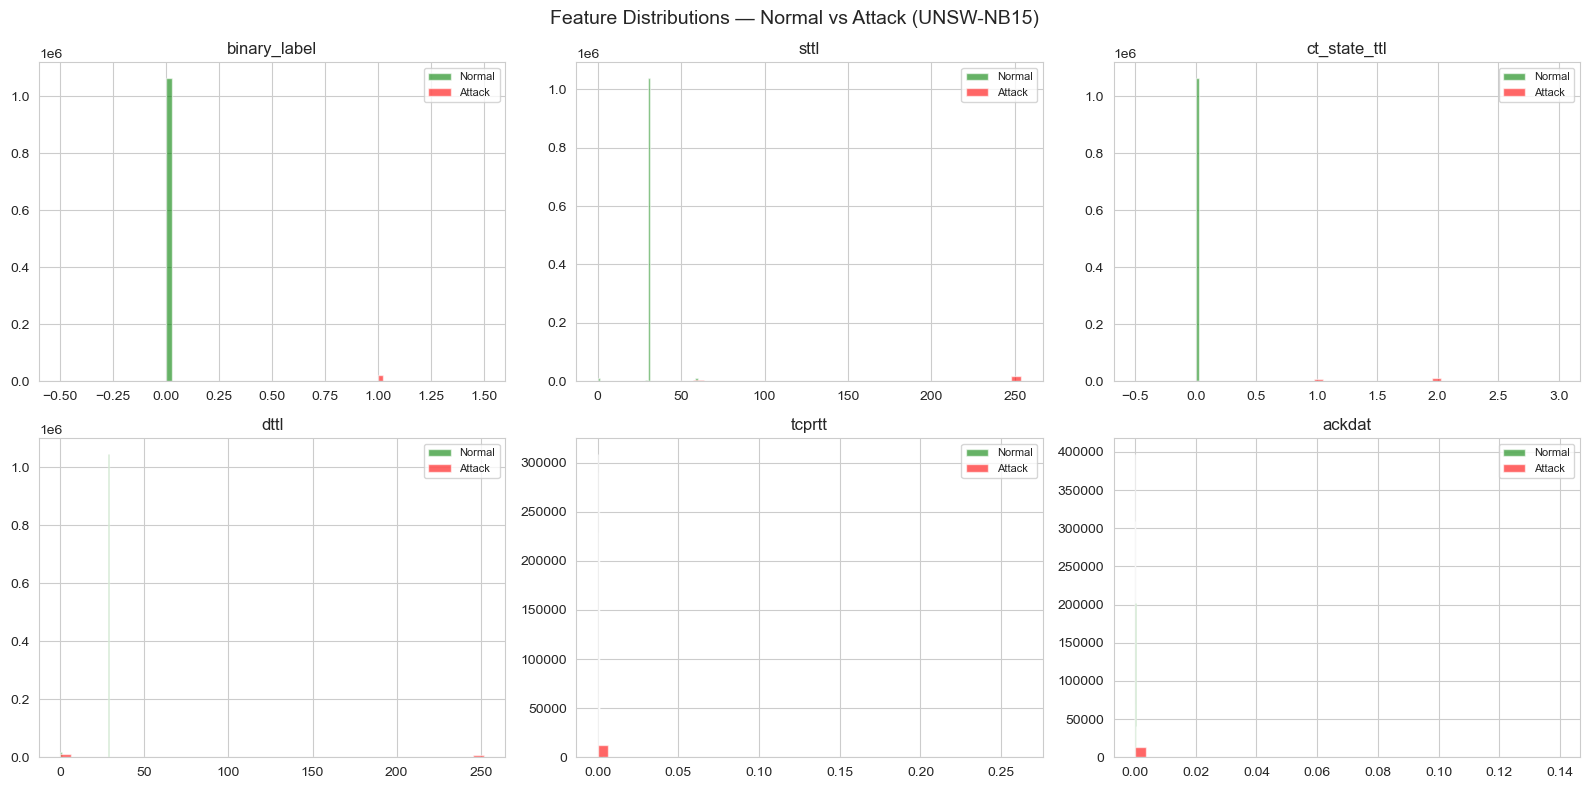

In [46]:
key_features = top_corr.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    normal = df[df['binary_label'] == 0][col]
    attack = df[df['binary_label'] == 1][col]
    axes[i].hist(normal.clip(upper=normal.quantile(0.99)), bins=40, alpha=0.6, label='Normal', color='green')
    axes[i].hist(attack.clip(upper=attack.quantile(0.99)), bins=40, alpha=0.6, label='Attack', color='red')
    axes[i].set_title(col[:30])
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions — Normal vs Attack (UNSW-NB15)', fontsize=14)
plt.tight_layout()
plt.show()

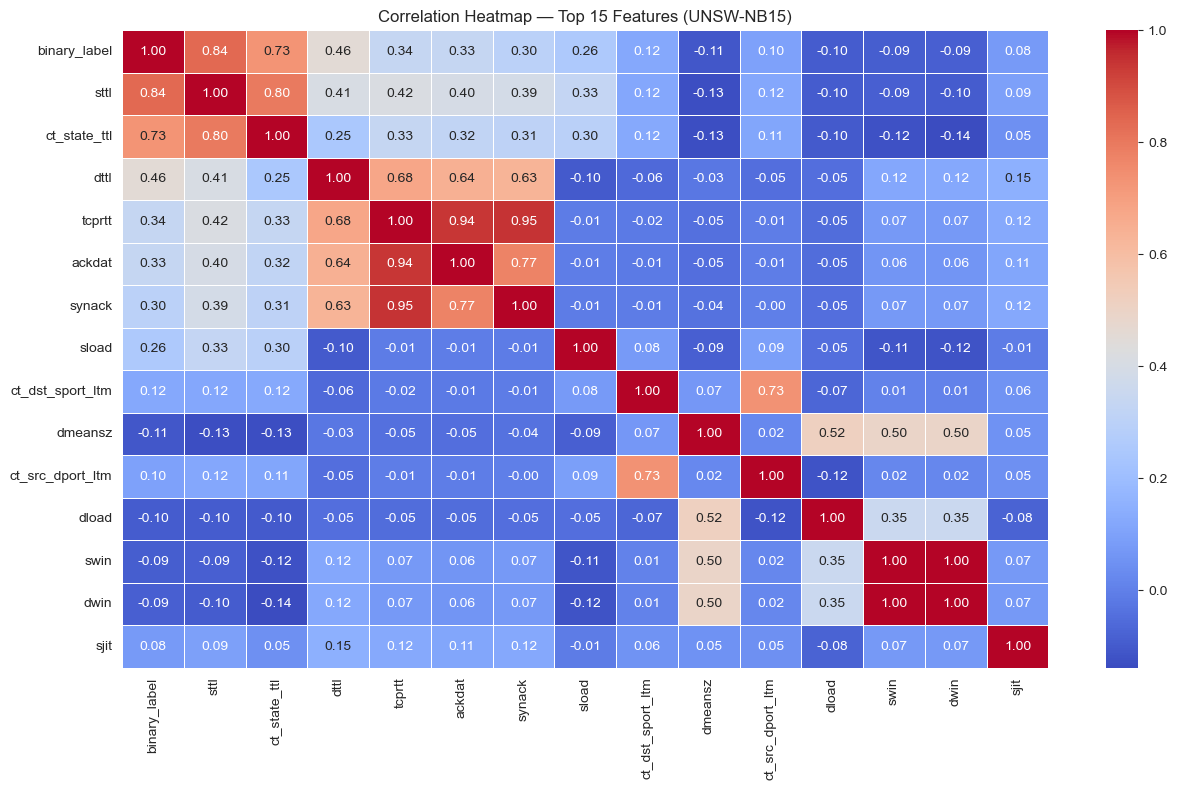

In [47]:
top15_cols = top_corr.index[:15].tolist()

plt.figure(figsize=(13, 8))
sns.heatmap(
    df[top15_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap — Top 15 Features (UNSW-NB15)')
plt.tight_layout()
plt.show()

In [48]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_data.csv', index=False)

print(f'Saved full cleaned UNSW-NB15 data')
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print(f'Path    : ../data/processed/cleaned_data.csv')
print(f'\n Next step: Open 02_feature_engineering.ipynb')

Saved full cleaned UNSW-NB15 data
Rows    : 1,087,203
Columns : 50
Path    : ../data/processed/cleaned_data.csv

 Next step: Open 02_feature_engineering.ipynb
